<a href="https://colab.research.google.com/github/kamiasa/1.Support_Vector_Machine/blob/main/004_SVC_1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC

In [ ]:
# Load Iris dataset
iris = load_iris()

In [ ]:
X = iris.data[:, :2]  # Only first 2 features (sepal length & width)
y = iris.target

In [ ]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
# Only keep 2 classes (binary classification)
X = X[y != 2]
y = y[y != 2]

In [ ]:
# Train Linear SVM
svm = SVC(kernel='linear')
svm.fit(X, y)

SVC(kernel='linear')

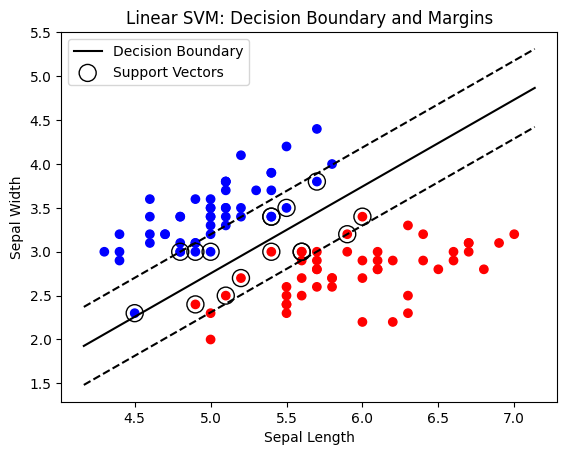

In [ ]:
# Draws all observations on a scatter plot
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

# Decision boundary and margins
ax = plt.gca()
x = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)

w = svm.coef_[0]
b = svm.intercept_[0]

# Decision boundary
y_decision = -(w[0] * x + b) / w[1]

# Margins
margin = 1 / np.sqrt(np.sum(w**2))    #the distance from the decision boundary to one margin
                                        #Calculate Margin Width

#Creates a parallel line above the decision boundary
y_margin_up = y_decision + np.sqrt(1 + (w[0]/w[1])**2) * margin

#Creates a parallel line below the decision boundary
y_margin_down = y_decision - np.sqrt(1 + (w[0]/w[1])**2) * margin

# Plot lines
plt.plot(x, y_decision, 'k-', label='Decision Boundary')
plt.plot(x, y_margin_up, 'k--')
plt.plot(x, y_margin_down, 'k--')

# Support vectors
plt.scatter(
    svm.support_vectors_[:, 0],     #Gets coordinates of support vectors
    svm.support_vectors_[:, 1],     #Gets coordinates of support vectors
    s=150,                            #Makes markers larger
    facecolors='none',                #Makes markers transparent
    edgecolors='black',               #Makes markers black
    label='Support Vectors'         #Adds legend label
)

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Linear SVM: Decision Boundary and Margins')
plt.legend()
plt.show()

In [ ]:
w

array([ 2.22720466, -2.24959915])

In [ ]:
b

np.float64(-4.9417851974386195)

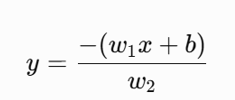